✅ Loaded 232,725 rows, 18 columns
   genre        artist_name                        track_name  \
0  Movie     Henri Salvador       C'est beau de faire un Show   
1  Movie  Martin & les fées  Perdu d'avance (par Gad Elmaleh)   
2  Movie    Joseph Williams    Don't Let Me Be Lonely Tonight   

                 track_id  popularity  acousticness  danceability  \
0  0BRjO6ga9RKCKjfDqeFgWV           0         0.611         0.389   
1  0BjC1NfoEOOusryehmNudP           1         0.246         0.590   
2  0CoSDzoNIKCRs124s9uTVy           3         0.952         0.663   

   duration_ms  energy  instrumentalness key  liveness  loudness   mode  \
0        99373   0.910               0.0  C#     0.346    -1.828  Major   
1       137373   0.737               0.0  F#     0.151    -5.559  Minor   
2       170267   0.131               0.0   C     0.103   -13.879  Minor   

   speechiness    tempo time_signature  valence  
0       0.0525  166.969            4/4    0.814  
1       0.0868  174.003    

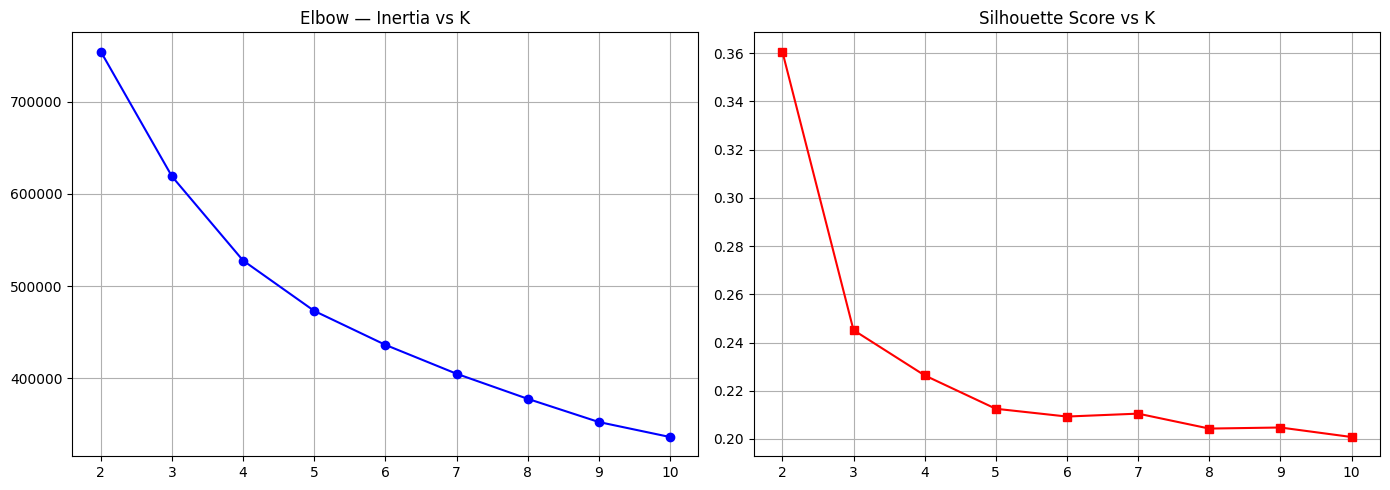


💡 Best K = 2
cluster
0    176782
1     55943
Name: count, dtype: int64


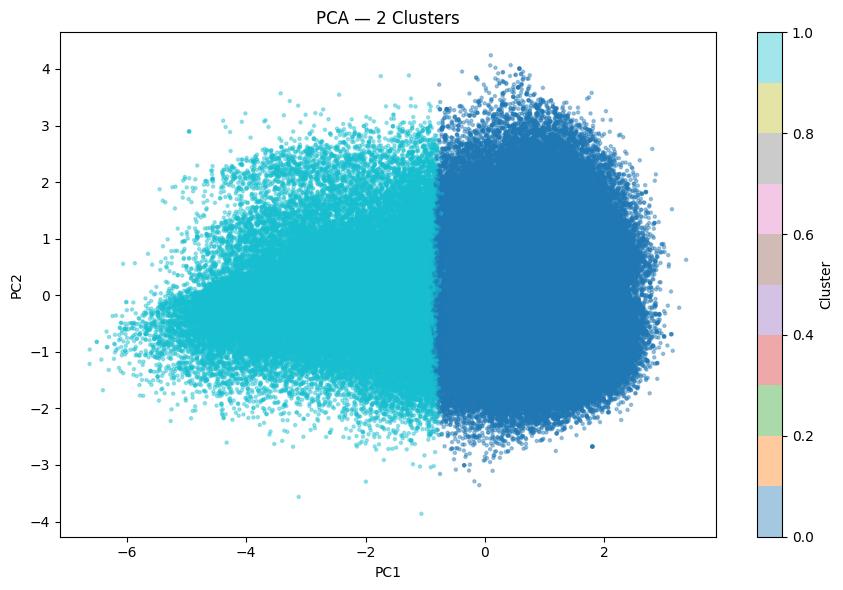

⏳ Running t-SNE...


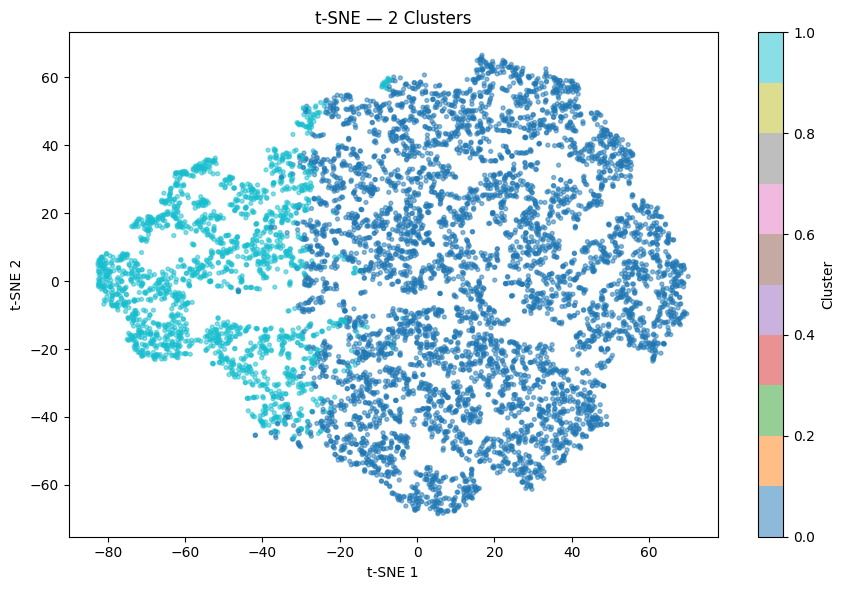

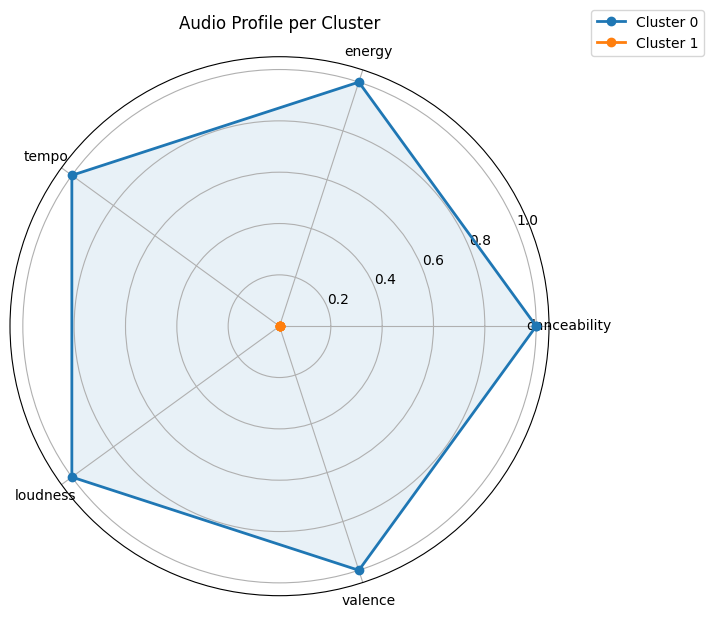


🎸 Top Genres per Cluster:
  cluster      genre    n
       0    Hip-Hop 9092
       0        Rap 9014
       0  Reggaeton 8912
       1 Soundtrack 8980
       1  Classical 8373
       1      Opera 8105

📊 Cluster Profiles:
         danceability  energy    tempo  loudness  valence
cluster                                                  
0               0.614   0.680  121.707    -7.099    0.534
1               0.365   0.225  104.898   -17.377    0.204


In [2]:
# ============================================================
# 🎵 Spotify Song Clustering — KMeans + PCA + t-SNE
# Upload CSV manually via Colab left sidebar → Files panel
# ============================================================

# ── Step 0: Libraries ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

# ── Step 1: Load CSV ──────────────────────────────────────────
# In Colab: click the 📁 Files icon (left sidebar) → Upload → select your CSV
# Then update the filename below if needed

df = pd.read_csv("/content/SpotifyFeatures.csv")   # ← change filename if different

print(f"✅ Loaded {df.shape[0]:,} rows, {df.shape[1]} columns")
print(df.head(3))

# ── Step 2: Select Features ───────────────────────────────────
FEATURES = ["danceability", "energy", "tempo", "loudness", "valence"]

data = df[FEATURES].dropna().reset_index(drop=True)
print(f"\n✅ {len(data):,} tracks ready for clustering")

# ── Step 3: Normalize ─────────────────────────────────────────
X_scaled = StandardScaler().fit_transform(data)

# ── Step 4: Elbow + Silhouette to Pick K ─────────────────────
inertia_vals, sil_vals = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(X_scaled, labels, sample_size=5000, random_state=42))
    print(f"  k={k}  Inertia={km.inertia_:.0f}  Silhouette={sil_vals[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertia_vals, "bo-"); axes[0].set_title("Elbow — Inertia vs K"); axes[0].grid(True)
axes[1].plot(list(K_range), sil_vals, "rs-");    axes[1].set_title("Silhouette Score vs K");  axes[1].grid(True)
plt.tight_layout(); plt.show()

BEST_K = list(K_range)[sil_vals.index(max(sil_vals))]
print(f"\n💡 Best K = {BEST_K}")

# ── Step 5: Final KMeans ──────────────────────────────────────
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X_scaled)
print(data["cluster"].value_counts().sort_index())

# ── Step 6: PCA Plot ──────────────────────────────────────────
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data["cluster"], cmap="tab10", alpha=0.4, s=5)
plt.colorbar(label="Cluster")
plt.title(f"PCA — {BEST_K} Clusters"); plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()

# ── Step 7: t-SNE Plot ────────────────────────────────────────
idx = np.random.choice(len(X_scaled), size=min(8000, len(X_scaled)), replace=False)
print("⏳ Running t-SNE...")
X_tsne = TSNE(n_components=2, perplexity=40, random_state=42).fit_transform(X_scaled[idx])

plt.figure(figsize=(9, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=data["cluster"].values[idx], cmap="tab10", alpha=0.5, s=8)
plt.colorbar(label="Cluster")
plt.title(f"t-SNE — {BEST_K} Clusters"); plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout(); plt.show()

# ── Step 8: Radar Chart ───────────────────────────────────────
profile = data.groupby("cluster")[FEATURES].mean()
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
angles = np.linspace(0, 2*np.pi, len(FEATURES), endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for i, row in profile_norm.iterrows():
    vals = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, vals, "o-", linewidth=2, label=f"Cluster {i}")
    ax.fill(angles, vals, alpha=0.1)
ax.set_thetagrids(np.degrees(angles[:-1]), FEATURES)
ax.set_title("Audio Profile per Cluster", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()

# ── Step 9: Genre Insights ────────────────────────────────────
if "genre" in df.columns:
    df_c = df.loc[data.index].copy()
    df_c["cluster"] = data["cluster"].values
    top = (df_c.groupby(["cluster","genre"]).size()
             .reset_index(name="n")
             .sort_values(["cluster","n"], ascending=[True,False])
             .groupby("cluster").head(3))
    print("\n🎸 Top Genres per Cluster:\n", top.to_string(index=False))

# ── Step 10: Summary ──────────────────────────────────────────
print("\n📊 Cluster Profiles:")
print(profile.round(3))